Cell 1 — Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = '/content/drive/MyDrive/PitWall'
DB_PATH      = f'{PROJECT_ROOT}/pitwall.db'
REPORTS_DIR  = f'{PROJECT_ROOT}/reports'
Path(REPORTS_DIR).mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)
print(f'DB: {DB_PATH}')

Mounted at /content/drive
DB: /content/drive/MyDrive/PitWall/pitwall.db


Cell 2 — Load raw tables

In [4]:
with sqlite3.connect(DB_PATH) as conn:
    results = pd.read_sql('SELECT * FROM results',                conn)
    qual    = pd.read_sql('SELECT * FROM qualifying',             conn)
    races   = pd.read_sql('SELECT * FROM races',                  conn)
    cs      = pd.read_sql('SELECT * FROM constructor_standings',  conn)
    constrs = pd.read_sql('SELECT * FROM constructors',           conn)

print(f'results               {results.shape}')
print(f'qualifying            {qual.shape}')
print(f'races                 {races.shape}')
print(f'constructor_standings {cs.shape}')
print(f'constructors          {constrs.shape}')

results               (4626, 14)
qualifying            (4610, 10)
races                 (228, 9)
constructor_standings (112, 7)
constructors          (214, 4)


Cell 3 — Parse qualifying times

In [6]:
def time_to_seconds(t):
    if pd.isna(t) or t == '':
        return np.nan
    try:
        s = str(t)
        if ':' in s:
            m, sec = s.split(':')
            return float(m) * 60 + float(sec)
        return float(s)
    except (ValueError, TypeError):
        return np.nan

q = qual.copy()
for col in ['q1', 'q2', 'q3']:
    q[f'{col}_sec'] = q[col].apply(time_to_seconds)

q['best_qual'] = q[['q1_sec', 'q2_sec', 'q3_sec']].min(axis=1)

pole = (q.groupby('race_id')['best_qual'].min()
          .reset_index().rename(columns={'best_qual': 'pole_time'}))
q = q.merge(pole, on='race_id', how='left')
q['gap_to_pole'] = q['best_qual'] - q['pole_time']

print(f'Records with parsed best_qual: {q["best_qual"].notna().sum()} / {len(q)}')
print(f'Median gap to pole: {q["gap_to_pole"].median():.3f}s')
print(f'Max gap to pole:    {q["gap_to_pole"].max():.3f}s')

Records with parsed best_qual: 4561 / 4610
Median gap to pole: 1.542s
Max gap to pole:    40.245s


Cell 4 — Qualifying features per team-season

In [7]:
qual_ts = q.groupby(['season', 'constructor_id']).agg(
    avg_qual_gap_to_pole    = ('gap_to_pole', 'mean'),
    median_qual_gap_to_pole = ('gap_to_pole', 'median'),
    pole_count              = ('position',    lambda x: (x == 1).sum()),
    avg_qual_position       = ('position',    'mean'),
).reset_index()

print(f'Shape: {qual_ts.shape}')
qual_ts.head()

Shape: (112, 6)


,season,constructor_id,avg_qual_gap_to_pole,median_qual_gap_to_pole,pole_count,avg_qual_position
0,2014,caterham,5.600182,4.690,0,20.058824
1,2014,ferrari,2.049684,1.499,0,8.289474
2,2014,force_india,2.237579,1.918,0,11.500000
3,2014,lotus_f1,3.286735,3.039,0,16.289474
4,2014,marussia,4.491645,4.138,0,18.967742


Cell 5 — Race features per team-season

In [8]:
res = results.copy()
res['finished'] = res['position'].notna().astype(int)

DNF_KEYWORDS = ['Accident','Collision','Mechanical','Engine','Gearbox','Hydraulics',
                'Electrical','Suspension','Brakes','Wheel','Tyre','Puncture',
                'Power Unit','Overheating','Oil','Retired']
res['is_dnf'] = res['status'].apply(
    lambda s: int(any(k.lower() in str(s).lower() for k in DNF_KEYWORDS))
)

res['on_podium'] = (res['position'].fillna(99) <= 3).astype(int)
res['won_race']  = (res['position'] == 1).astype(int)
res['qual_to_race_delta'] = res['position'] - res['grid']

race_ts = res.groupby(['season', 'constructor_id']).agg(
    total_points           = ('points',     'sum'),
    total_wins             = ('won_race',   'sum'),
    total_podiums          = ('on_podium',  'sum'),
    total_dnfs             = ('is_dnf',     'sum'),
    races_entered          = ('race_id',    'nunique'),
    n_starts               = ('result_id',  'count'),
    avg_grid               = ('grid',       'mean'),
    avg_finish_position    = ('position',   'mean'),
    finish_rate            = ('finished',   'mean'),
    avg_qual_to_race_delta = ('qual_to_race_delta', 'mean'),
).reset_index()

race_ts['dnf_rate'] = race_ts['total_dnfs'] / race_ts['n_starts']

print(f'Shape: {race_ts.shape}')
race_ts.head()

Shape: (112, 13)


,season,constructor_id,total_points,total_wins,total_podiums,total_dnfs,races_entered,n_starts,avg_grid,avg_finish_position,finish_rate,avg_qual_to_race_delta,dnf_rate
0,2014,caterham,0.0,0,0,12,17,34,19.441176,17.823529,1.0,-1.617647,0.352941
1,2014,ferrari,216.0,0,2,2,19,38,7.947368,8.473684,1.0,0.526316,0.052632
2,2014,force_india,155.0,0,1,6,19,38,11.500000,9.973684,1.0,-1.526316,0.157895
3,2014,lotus_f1,10.0,0,0,7,19,38,16.315789,15.157895,1.0,-1.157895,0.184211
4,2014,marussia,2.0,0,0,7,16,31,18.677419,16.806452,1.0,-1.870968,0.225806


Cell 6 — Merge into team_season_stats

In [9]:
team_season = race_ts.merge(qual_ts, on=['season', 'constructor_id'], how='left')

final_cs = (cs.sort_values('round')
              .groupby(['season', 'constructor_id']).last().reset_index()
              [['season', 'constructor_id', 'position', 'wins']]
              .rename(columns={'position': 'season_rank', 'wins': 'official_wins'}))

team_season = team_season.merge(final_cs, on=['season', 'constructor_id'], how='left')
team_season = team_season.merge(constrs[['constructor_id', 'name', 'nationality']],
                                on='constructor_id', how='left')

for col in ['total_points', 'total_wins', 'total_podiums']:
    season_max = team_season.groupby('season')[col].transform('max')
    team_season[f'{col}_norm'] = (team_season[col] / season_max.replace(0, np.nan)).fillna(0)

team_season = team_season.sort_values(['season', 'season_rank']).reset_index(drop=True)
print(f'Shape: {team_season.shape}')
team_season.head()

Shape: (112, 24)


,season,constructor_id,total_points,total_wins,total_podiums,total_dnfs,races_entered,n_starts,avg_grid,avg_finish_position,finish_rate,avg_qual_to_race_delta,dnf_rate,avg_qual_gap_to_pole,median_qual_gap_to_pole,pole_count,avg_qual_position,season_rank,official_wins,name,nationality,total_points_norm,total_wins_norm,total_podiums_norm
0,2014,mercedes,701.0,16,31,5,19,38,2.947368,4.210526,1.0,1.263158,0.131579,0.252405,0.0190,18,2.815789,1,16,Mercedes,German,1.000000,1.0000,1.000000
1,2014,red_bull,405.0,3,12,3,19,38,7.026316,6.736842,1.0,-0.289474,0.078947,1.193333,1.0470,0,6.027778,2,3,Red Bull,Austrian,0.577746,0.1875,0.387097
2,2014,williams,320.0,0,9,5,19,38,6.842105,7.815789,1.0,0.973684,0.131579,1.703737,0.8325,1,6.842105,3,0,Williams,British,0.456491,0.0000,0.290323
3,2014,ferrari,216.0,0,2,2,19,38,7.947368,8.473684,1.0,0.526316,0.052632,2.049684,1.4990,0,8.289474,4,0,Ferrari,Italian,0.308131,0.0000,0.064516
4,2014,mclaren,181.0,0,2,1,19,38,8.631579,8.947368,1.0,0.315789,0.026316,1.694237,1.5725,0,8.236842,5,0,McLaren,British,0.258203,0.0000,0.064516


Cell 7 — Persist team_season_stats

In [10]:
with sqlite3.connect(DB_PATH) as conn:
    team_season.to_sql('team_season_stats', conn, if_exists='replace', index=False)
    n = pd.read_sql('SELECT COUNT(*) AS n FROM team_season_stats', conn).iloc[0, 0]
    print(f'team_season_stats persisted: {n} rows')
    print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn))

team_season_stats persisted: 112 rows
                    name
0  constructor_standings
1           constructors
2       driver_standings
3                drivers
4       qual_times_clean
5             qualifying
6                  races
7                results
8        sqlite_sequence
9      team_season_stats


Cell 8 — Real correlation

In [11]:
mask = team_season['avg_qual_gap_to_pole'].notna() & team_season['total_points'].notna()
sub  = team_season[mask]

r_full = np.corrcoef(sub['avg_qual_gap_to_pole'], sub['total_points'])[0, 1]
print(f'Pearson r, all {len(sub)} team-seasons: {r_full:.3f}')

top6 = sub.groupby('constructor_id')['total_points'].sum().nlargest(6).index
sub6 = sub[sub['constructor_id'].isin(top6)]
r_t6 = np.corrcoef(sub6['avg_qual_gap_to_pole'], sub6['total_points'])[0, 1]
print(f'Pearson r, top-6 only ({len(sub6)} team-seasons): {r_t6:.3f}')

Pearson r, all 112 team-seasons: -0.787
Pearson r, top-6 only (60 team-seasons): -0.887


Cell 9 — Feature matrix

In [12]:
FEATURE_COLS = [
    'avg_grid', 'avg_qual_gap_to_pole', 'pole_count',
    'finish_rate', 'dnf_rate', 'avg_qual_to_race_delta',
    'races_entered', 'season',
]
TARGET = 'total_points'

features = (team_season[['season', 'constructor_id', 'name'] + FEATURE_COLS + [TARGET]]
            .dropna(subset=FEATURE_COLS + [TARGET])
            .reset_index(drop=True))

print(f'Final feature matrix: {features.shape}')
print(f'Rows dropped due to NaN: {len(team_season) - len(features)}')
print(features[FEATURE_COLS + [TARGET]].describe().round(2))

Final feature matrix: (112, 12)
Rows dropped due to NaN: 0
       avg_grid  avg_qual_gap_to_pole  pole_count  finish_rate  dnf_rate  \
count    112.00                112.00      112.00        112.0    112.00   
mean      10.48                  1.96        2.04          1.0      0.15   
std        4.42                  1.18        4.54          0.0      0.08   
min        1.82                  0.22        0.00          1.0      0.00   
25%        6.82                  1.09        0.00          1.0      0.08   
50%       10.87                  1.94        0.00          1.0      0.13   
75%       13.84                  2.55        1.00          1.0      0.20   
max       19.44                  6.36       20.00          1.0      0.39   

       avg_qual_to_race_delta  races_entered   season   season  total_points  
count                  112.00         112.00   112.00   112.00        112.00  
mean                     0.20          20.66  2018.93  2018.93        207.07  
std                

Cell 10 — Persist feature matrix

In [14]:
with sqlite3.connect(DB_PATH) as conn:
    # Remove duplicate 'season' column before writing to SQL
    features_cleaned = features.loc[:, ~features.columns.duplicated()]
    features_cleaned.to_sql('team_season_features', conn, if_exists='replace', index=False)
    n = pd.read_sql('SELECT COUNT(*) AS n FROM team_season_features', conn).iloc[0, 0]
    print(f'team_season_features persisted: {n} rows, {len(FEATURE_COLS)} features + target')
    print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn))

team_season_features persisted: 112 rows, 8 features + target
                     name
0   constructor_standings
1            constructors
2        driver_standings
3                 drivers
4        qual_times_clean
5              qualifying
6                   races
7                 results
8         sqlite_sequence
9    team_season_features
10      team_season_stats


Cell 11 — Correlation heatmap

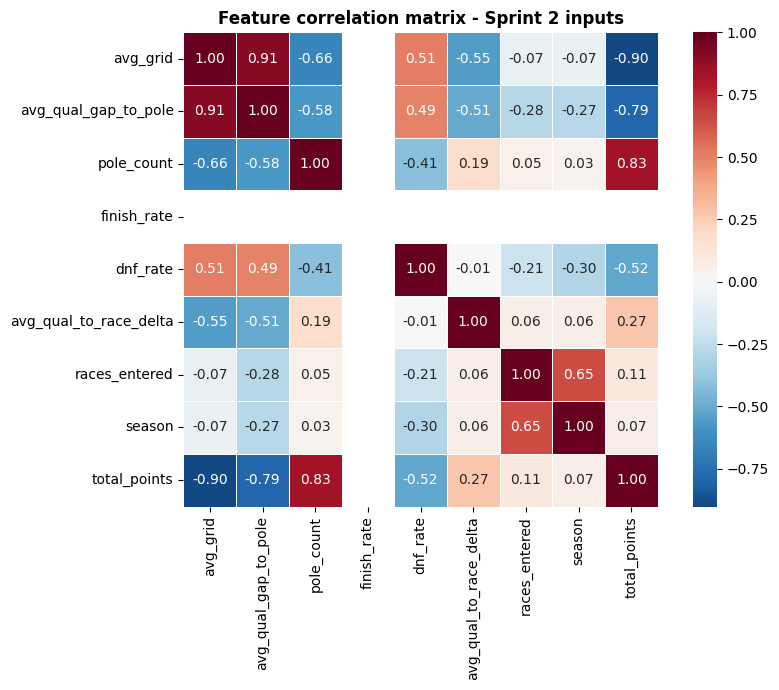

Features ranked by |r| with total_points:
avg_grid                 -0.902
pole_count                0.831
avg_qual_gap_to_pole     -0.787
dnf_rate                 -0.522
avg_qual_to_race_delta    0.275
races_entered             0.106
season                    0.067
finish_rate                 NaN
Name: total_points, dtype: float64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use features_cleaned to avoid duplicate 'season' column
corr = features_cleaned[FEATURE_COLS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature correlation matrix - Sprint 2 inputs',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/sprint2_01_feature_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print('Features ranked by |r| with total_points:')
print(corr[TARGET].drop(TARGET).reindex(
    corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).index
).round(3))